In [11]:
import pandas as pd
import matplotlib as mp

In [15]:
df=pd.read_csv(r"C:\Users\VISHAL SINGH\OneDrive\Desktop\country_wise_latest.csv")

In [16]:
df.head(5)

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


In [17]:
df.shape

(187, 15)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    object 
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               187 non-null    int64  
 6   New deaths              187 non-null    int64  
 7   New recovered           187 non-null    int64  
 8   Deaths / 100 Cases      187 non-null    float64
 9   Recovered / 100 Cases   187 non-null    float64
 10  Deaths / 100 Recovered  187 non-null    float64
 11  Confirmed last week     187 non-null    int64  
 12  1 week change           187 non-null    int64  
 13  1 week % increase       187 non-null    float64
 14  WHO Region              187 non-null    ob

In [21]:
df.isnull().sum()

Country/Region            0
Confirmed                 0
Deaths                    0
Recovered                 0
Active                    0
New cases                 0
New deaths                0
New recovered             0
Deaths / 100 Cases        0
Recovered / 100 Cases     0
Deaths / 100 Recovered    0
Confirmed last week       0
1 week change             0
1 week % increase         0
WHO Region                0
dtype: int64

In [27]:
df.duplicated().sum()

np.int64(0)

In [30]:
df=df[['Country/Region','Confirmed','Deaths','Recovered','Active','New cases']]

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Country/Region  187 non-null    object
 1   Confirmed       187 non-null    int64 
 2   Deaths          187 non-null    int64 
 3   Recovered       187 non-null    int64 
 4   Active          187 non-null    int64 
 5   New cases       187 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 8.9+ KB


In [51]:
countries = ['India','Brazil','Australia']
df = df[df['Country/Region'].isin(countries)]


In [52]:
df.head(10)

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases
8,Australia,15303,167,9311,5825,368
23,Brazil,2442375,87618,1846641,508116,23284
79,India,1480073,33408,951166,495499,44457


In [54]:
df.groupby('Country/Region')['Confirmed'].max()


Country/Region
Australia      15303
Brazil       2442375
India        1480073
Name: Confirmed, dtype: int64

In [57]:
 df.groupby('Country/Region')['New cases'].sum()


Country/Region
Australia      368
Brazil       23284
India        44457
Name: New cases, dtype: int64

In [58]:
df['death_rate'] = df['Deaths'] / df['New cases']


In [59]:
df

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,death_rate
8,Australia,15303,167,9311,5825,368,0.453804
23,Brazil,2442375,87618,1846641,508116,23284,3.763013
79,India,1480073,33408,951166,495499,44457,0.751468


In [60]:
df.groupby('Country/Region')['death_rate'].mean()


Country/Region
Australia    0.453804
Brazil       3.763013
India        0.751468
Name: death_rate, dtype: float64

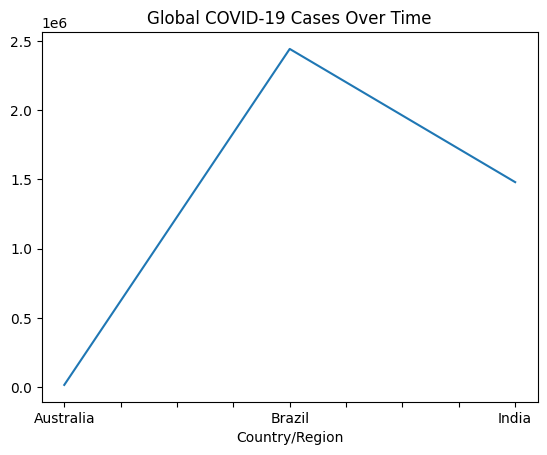

In [64]:
import matplotlib.pyplot as plt

global_cases = df.groupby('Country/Region')['Confirmed'].sum()
global_cases.plot()
plt.title("Global COVID-19 Cases Over Time")
plt.show()


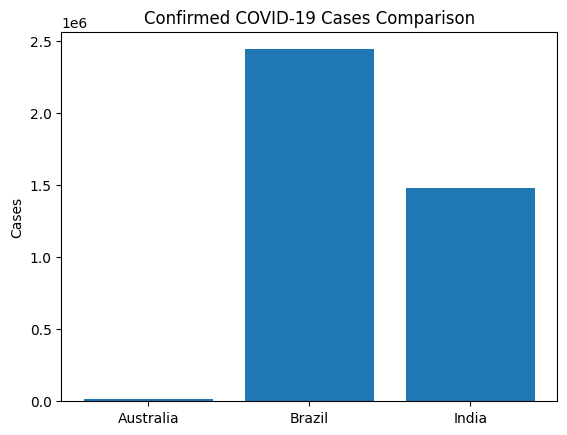

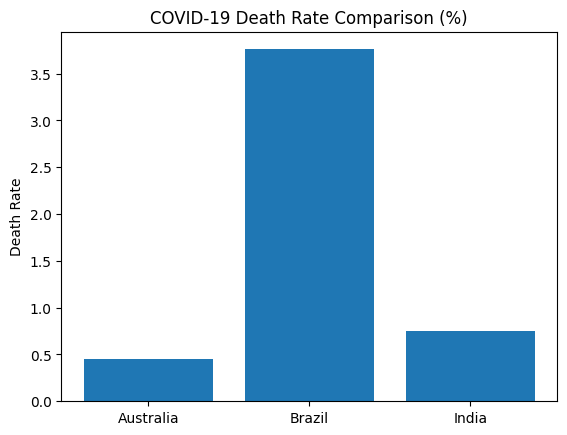

In [67]:
import matplotlib.pyplot as plt

countries = ['Australia', 'Brazil', 'India']
confirmed = [15303, 2442375, 1480073]
deaths = [167, 87618, 33408]
death_rate = [0.45, 3.76, 0.75]

plt.figure()
plt.bar(countries, confirmed)
plt.title("Confirmed COVID-19 Cases Comparison")
plt.ylabel("Cases")
plt.show()

plt.figure()
plt.bar(countries, death_rate)
plt.title("COVID-19 Death Rate Comparison (%)")
plt.ylabel("Death Rate")
plt.show()


In [68]:
df['Cases_per_100k'] = (df['Confirmed'] / 100000) * 100
df['Deaths_per_100k'] = (df['Deaths'] / 100000) * 100


In [69]:
df

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,death_rate,Cases_per_100k,Deaths_per_100k
8,Australia,15303,167,9311,5825,368,0.453804,15.303,0.167
23,Brazil,2442375,87618,1846641,508116,23284,3.763013,2442.375,87.618
79,India,1480073,33408,951166,495499,44457,0.751468,1480.073,33.408


In [72]:
def risk_level(row):
    if row['death_rate'] > 3:
        return 'High Risk'
    elif row['death_rate'] > 1:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['Risk_Level'] = df.apply(risk_level, axis=1)


In [74]:
df


,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,death_rate,Cases_per_100k,Deaths_per_100k,Risk_Level
8,Australia,15303,167,9311,5825,368,0.453804,15.303,0.167,Low Risk
23,Brazil,2442375,87618,1846641,508116,23284,3.763013,2442.375,87.618,High Risk
79,India,1480073,33408,951166,495499,44457,0.751468,1480.073,33.408,Low Risk


In [76]:
for _, row in df.iterrows():
    print(f"{row['Country/Region']} is categorized as {row['Risk_Level']} with a death rate of {row['death_rate']:.2f}%.")


Australia is categorized as Low Risk with a death rate of 0.45%.
Brazil is categorized as High Risk with a death rate of 3.76%.
India is categorized as Low Risk with a death rate of 0.75%.


In [77]:
df['Severity_Rank'] = df['death_rate'].rank(ascending=False)


In [78]:
df

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,death_rate,Cases_per_100k,Deaths_per_100k,Risk_Level,Severity_Rank
8,Australia,15303,167,9311,5825,368,0.453804,15.303,0.167,Low Risk,3.0
23,Brazil,2442375,87618,1846641,508116,23284,3.763013,2442.375,87.618,High Risk,1.0
79,India,1480073,33408,951166,495499,44457,0.751468,1480.073,33.408,Low Risk,2.0


In [79]:
df.to_csv("covid_analysis_summary.csv", index=False)


In [80]:
df['Deaths_if_1pct'] = df['Confirmed'] * 0.01


In [81]:
df

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,death_rate,Cases_per_100k,Deaths_per_100k,Risk_Level,Severity_Rank,Deaths_if_1pct
8,Australia,15303,167,9311,5825,368,0.453804,15.303,0.167,Low Risk,3.0,153.03
23,Brazil,2442375,87618,1846641,508116,23284,3.763013,2442.375,87.618,High Risk,1.0,24423.75
79,India,1480073,33408,951166,495499,44457,0.751468,1480.073,33.408,Low Risk,2.0,14800.73


In [82]:
df.pop('Deaths_if_1pct')
print(df)

   Country/Region  Confirmed  Deaths  Recovered  Active  New cases  \
8       Australia      15303     167       9311    5825        368   
23         Brazil    2442375   87618    1846641  508116      23284   
79          India    1480073   33408     951166  495499      44457   

    death_rate  Cases_per_100k  Deaths_per_100k Risk_Level  Severity_Rank  
8     0.453804          15.303            0.167   Low Risk            3.0  
23    3.763013        2442.375           87.618  High Risk            1.0  
79    0.751468        1480.073           33.408   Low Risk            2.0  


In [83]:
df

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,death_rate,Cases_per_100k,Deaths_per_100k,Risk_Level,Severity_Rank
8,Australia,15303,167,9311,5825,368,0.453804,15.303,0.167,Low Risk,3.0
23,Brazil,2442375,87618,1846641,508116,23284,3.763013,2442.375,87.618,High Risk,1.0
79,India,1480073,33408,951166,495499,44457,0.751468,1480.073,33.408,Low Risk,2.0


In [85]:
def executive_summary(df):
    worst = df.loc[df['death_rate'].idxmax()]
    best = df.loc[df['death_rate'].idxmin()]

    return f"""
    EXECUTIVE SUMMARY:
    {worst['Country/Region']} shows the highest severity with a death rate of {worst['death_rate']:.2f}%.
    {best['Country/Region']} demonstrates effective containment with a death rate of {best['death_rate']:.2f}%.
    Strategic interventions should focus on high-risk regions.
    """

print(executive_summary(df))



    EXECUTIVE SUMMARY:
    Brazil shows the highest severity with a death rate of 3.76%.
    Australia demonstrates effective containment with a death rate of 0.45%.
    Strategic interventions should focus on high-risk regions.
    
